# ANN & MNIST : exercise

## 라이브러리 불러오기

In [52]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random as rd

from sklearn.metrics import accuracy_score

## 데이터 불러오기

In [125]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

In [126]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [127]:
train_x[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

id = 0
다음 그림은 숫자 5 입니다.


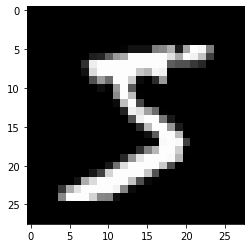

In [95]:
'''
Ctrl+Enter를 이용하여
반복 실행 해보자!
'''

# id = rd.randrange(0,10000)
id = 0

print(f'id = {id}')
print(f'다음 그림은 숫자 {train_y[id]} 입니다.')

plt.imshow(train_x[id], cmap='gray')
plt.show()

## 데이터 전처리

* reshape

In [96]:
train_x.shape[0]

60000

In [128]:
train_x=train_x.reshape([train_x.shape[0],-1])

In [129]:
test_x = test_x.reshape([test_x.shape[0],-1])

In [116]:
train_x.shape

(60000, 784)

* min-max scaling

In [130]:
max_n,min_n=train_x.max(),train_x.min()
max_n,min_n

(255, 0)

In [131]:
train_x=(train_x-min_n)/(max_n-min_n)
test_x=(test_x-min_n)/(max_n-min_n)

In [100]:
print(f'max : {train_x.max()} / min : {train_x.min()}')

max : 1.0 / min : 0.0


* target feature : One-hot Encoding

In [132]:
from tensorflow.keras.utils import to_categorical
len_y = len(set(train_y))
train_y=to_categorical(train_y,len_y)
test_y = to_categorical(test_y, len_y)

In [133]:
train_y.shape

(60000, 10)

## 모델링 I

1. Sequential, Functional 아무 것이나!
2. 히든레이어 없이 epochs=50 으로 성능 관찰.
3. activation, loss 설정
4. Early Stopping

In [65]:
train_x.shape,train_y.shape

((60000, 784), (60000, 10))

In [74]:
########################
# 모델링 I : .fit( ) 까지!
########################
keras.backend.clear_session()
il=keras.layers.Input(shape=(784))
ol=keras.layers.Dense(10,activation='softmax')(il)
model=keras.models.Model(inputs=il,outputs=ol)
model.compile(loss=keras.losses.categorical_crossentropy,metrics=['accuracy'],optimizer='adam')
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 10)                7850      
                                                                 
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________


In [75]:
from tensorflow.keras.callbacks import EarlyStopping

In [76]:
es = EarlyStopping(monitor='val_loss', #관측대상
                   min_delta=0, # 최소한 나빠지지 않으면 괜찮아
                   patience=5, # 성능 개선되지 않는걸 얼마나 참을래?
                   verbose=1, 
                   restore_best_weights=True) # 학습이 멈췄을때, 최적의 가중치로 전환해줌

In [77]:
model.fit(train_x,train_y,epochs=50,verbose=1,callbacks=[es],validation_split=0.2)

Epoch 1/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.5083 - accuracy: 0.8674 - val_loss: 0.3171 - val_accuracy: 0.9133
Epoch 2/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3174 - accuracy: 0.9117 - val_loss: 0.2850 - val_accuracy: 0.9209
Epoch 3/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2937 - accuracy: 0.9183 - val_loss: 0.2763 - val_accuracy: 0.9233
Epoch 4/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2816 - accuracy: 0.9203 - val_loss: 0.2702 - val_accuracy: 0.9247
Epoch 5/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2737 - accuracy: 0.9229 - val_loss: 0.2715 - val_accuracy: 0.9253
Epoch 6/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2676 - accuracy: 0.9254 - val_loss: 0.2649 - val_accuracy: 0.9273
Epoch 7/50
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2642 - accuracy: 0.9262 - val_loss: 0.2655 - val_accuracy:

In [31]:
pred_train = model.predict(train_x)
pred_test = model.predict(test_x)

single_pred_train = pred_train.argmax(axis=1)
single_pred_test = pred_test.argmax(axis=1)

logi_train_accuracy = accuracy_score(train_y.argmax(axis=1), single_pred_train)
logi_test_accuracy = accuracy_score(test_y.argmax(axis=1), single_pred_test)

print('트레이닝 정확도 : {:.2f}%'.format(logi_train_accuracy*100))
print('테스트 정확도 : {:.2f}%'.format(logi_test_accuracy*100))

트레이닝 정확도 : 93.36%
테스트 정확도 : 92.76%


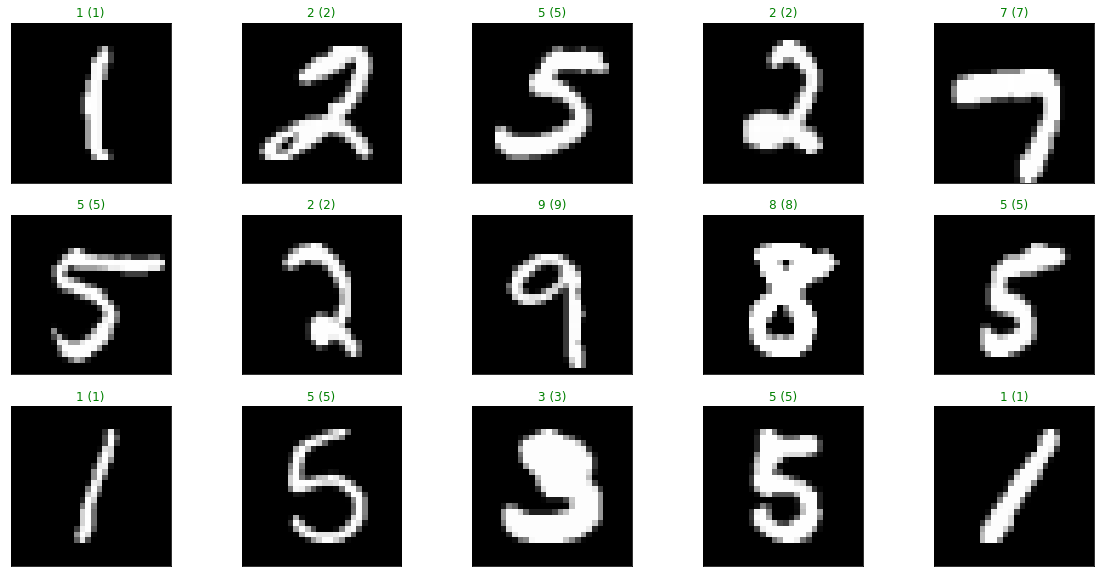

In [32]:
mnist_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

figure = plt.figure(figsize=(20, 10))

for i, index in enumerate(np.random.choice(test_x.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(test_x[index].reshape([28,-1])), cmap='gray' )
    
    predict_index = pred_test[index].argmax(axis=0)
    true_index = test_y[index].argmax(axis=0)
    # Set the title for each image
    ax.set_title(f"{mnist_labels[predict_index]} ({mnist_labels[true_index]})",
                 color=("green" if predict_index == true_index else "red"))

id = 149
다음 그림은 숫자 2 입니다.
모델의 예측 : 9
모델의 카테고리별 확률 : [ 0.  0.  1.  0.  1.  0.  0.  0.  0. 94.]
틀렸어요


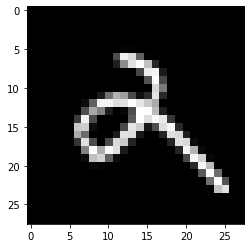

In [33]:
'''
틀린 것만 관찰해보자!

Ctrl+Enter를 이용하여
반복 실행 해보자!
'''

true_false = (test_y.argmax(axis=1) == single_pred_test)
f_id = np.where(true_false == False)[0]
f_n = len(f_id)

id = f_id[rd.randrange(0,f_n)]

print(f'id = {id}' )
print(f'다음 그림은 숫자 {test_y.argmax(axis=1)[id]} 입니다.')
print(f'모델의 예측 : {single_pred_test[id]}')
print(f'모델의 카테고리별 확률 : {np.floor(pred_test[id]*100)}')

if test_y.argmax(axis=1)[id] == single_pred_test[id] :
    print('===============')
    print('정답입니다')
    print('===============')
else : 
    print('===============')
    print('틀렸어요')
    print('===============')

plt.imshow(test_x[id].reshape([28,-1]), cmap='gray')
plt.show()

In [34]:
model.evaluate(test_x, test_y)

313/313 [==============================] - 1s 2ms/step - loss: 0.2667 - accuracy: 0.9276


[0.26667457818984985, 0.9276000261306763]



---



## 모델링 II

1. Sequential, Functional 아무 것이나!
2. 히든레이어 3개 이상 쌓고, epochs=50 으로 성능 관찰.
3. activation, loss 설정
4. Early Stopping

In [150]:
train_x.shape #reshape해서 1차원 형태

(60000, 784)

In [146]:
#########################
# 모델링 II : .fit( ) 까지!
#########################
keras.backend.clear_session()
model=keras.models.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(512,activation='relu'))
model.add(keras.layers.Dense(32,activation='relu'))
model.add(keras.layers.Dense(32,activation='relu'))
model.add(keras.layers.Dense(20,activation='softmax'))
model.compile(loss = keras.losses.sparse_categorical_crossentropy, optimizer = 'adam', metrics=['accuracy'])

In [157]:
keras.backend.clear_session()
il=keras.layers.Input(shape=(784,))
hl=keras.layers.Dense(512,activation='relu')(il)
hl=keras.layers.Dense(512,activation='relu')(hl)
hl=keras.layers.Dense(512,activation='relu')(hl)
ol=keras.layers.Dense(10,activation='softmax')(hl)
model=keras.models.Model(inputs=il,outputs=ol)
model.compile(loss = keras.losses.categorical_crossentropy, optimizer = 'adam', metrics=['accuracy'])

In [158]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dense_2 (Dense)             (None, 512)               262656    
                                                                 
 dense_3 (Dense)             (None, 10)                5130      
                                                                 
Total params: 932,362
Trainable params: 932,362
Non-trainable params: 0
_________________________________________________________________


In [159]:
es=EarlyStopping(monitor='val_loss', #무엇을 관측
                 min_delta=0, # 0이면 최소한 성능이 나빠지지만 않으면 멈출래
                 patience=5, # 최고 성능 5번까지 참아
                 verbose=1, # 어디서 멈추는 보여줄거야
                 restore_best_weights=True) # 최고 성능 가중치 모델에 넣을 거야

In [160]:
model.fit(train_x, train_y, validation_split=0.2, callbacks=[es], #Earlystopping 적용
          verbose=1, epochs=50)

Epoch 1/50
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2145 - accuracy: 0.9338 - val_loss: 0.2050 - val_accuracy: 0.9362
Epoch 2/50
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0981 - accuracy: 0.9707 - val_loss: 0.1028 - val_accuracy: 0.9705
Epoch 3/50
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0699 - accuracy: 0.9794 - val_loss: 0.1117 - val_accuracy: 0.9715
Epoch 4/50
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0567 - accuracy: 0.9825 - val_loss: 0.1007 - val_accuracy: 0.9760
Epoch 5/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0460 - accuracy: 0.9858 - val_loss: 0.1102 - val_accuracy: 0.9707
Epoch 6/50
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0408 - accuracy: 0.9871 - val_loss: 0.1018 - val_accuracy: 0.9761
Epoch 7/50
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0330 - accuracy: 0.9902 - val_loss: 0.1028 - val_accuracy:

In [161]:
pred_train = model.predict(train_x)
pred_test = model.predict(test_x)

single_pred_train = pred_train.argmax(axis=1)
single_pred_test = pred_test.argmax(axis=1)

logi_train_accuracy = accuracy_score(train_y.argmax(axis=1), single_pred_train)
logi_test_accuracy = accuracy_score(test_y.argmax(axis=1), single_pred_test)

print('트레이닝 정확도 : {:.2f}%'.format(logi_train_accuracy*100))
print('테스트 정확도 : {:.2f}%'.format(logi_test_accuracy*100))

트레이닝 정확도 : 98.74%
테스트 정확도 : 97.70%


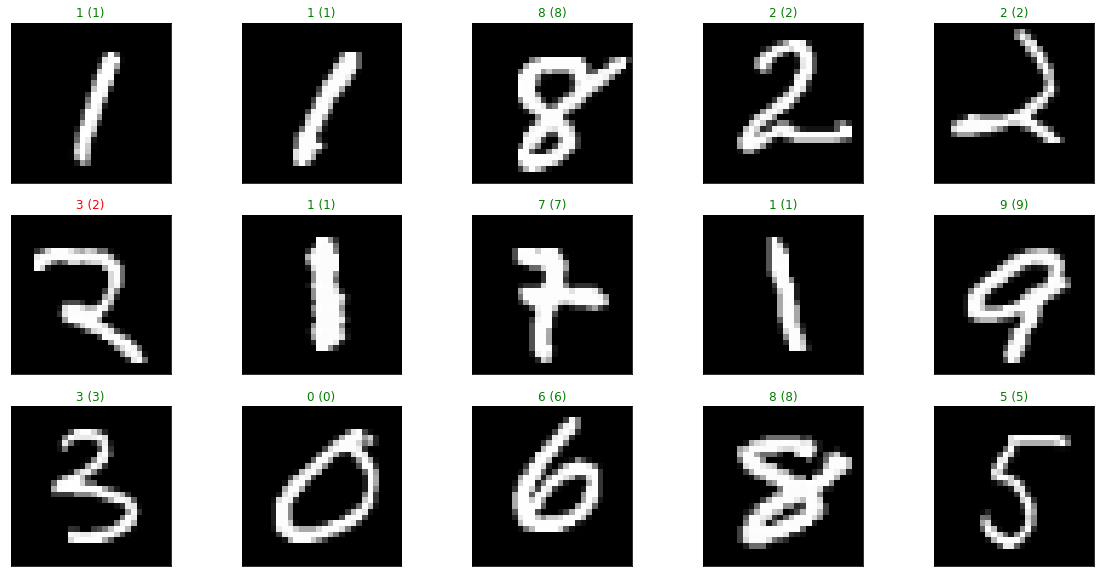

In [162]:
mnist_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

figure = plt.figure(figsize=(20, 10))

for i, index in enumerate(np.random.choice(test_x.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(test_x[index].reshape([28,-1])), cmap='gray' )
    
    predict_index = pred_test[index].argmax(axis=0)
    true_index = test_y[index].argmax(axis=0)
    # Set the title for each image
    ax.set_title(f"{mnist_labels[predict_index]} ({mnist_labels[true_index]})",
                 color=("green" if predict_index == true_index else "red"))

id = 6045
다음 그림은 숫자 3 입니다.
모델의 예측 : 8
모델의 카테고리별 확률 : [ 0.  0.  0. 30.  0.  1.  0.  0. 60.  6.]
틀렸어요


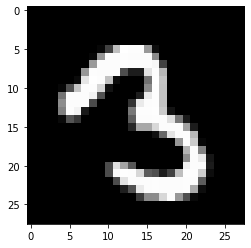

In [163]:
'''
틀린 것만 관찰해보자!

Ctrl+Enter를 이용하여
반복 실행 해보자!
'''

true_false = (test_y.argmax(axis=1) == single_pred_test)
f_id = np.where(true_false == False)[0]
f_n = len(f_id)

id = f_id[rd.randrange(0,f_n)]

print(f'id = {id}' )
print(f'다음 그림은 숫자 {test_y.argmax(axis=1)[id]} 입니다.')
print(f'모델의 예측 : {single_pred_test[id]}')
print(f'모델의 카테고리별 확률 : {np.floor(pred_test[id]*100)}')

if test_y.argmax(axis=1)[id] == single_pred_test[id] :
    print('===============')
    print('정답입니다')
    print('===============')
else : 
    print('===============')
    print('틀렸어요')
    print('===============')

plt.imshow(test_x[id].reshape([28,-1]), cmap='gray')
plt.show()

In [164]:
model.evaluate(test_x, test_y)

313/313 [==============================] - 1s 3ms/step - loss: 0.0887 - accuracy: 0.9770


[0.08866768330335617, 0.9769999980926514]

1. 실습에서는 28*28에서 이미지 구조를 살려서 flatten() 사용해서 펼침
2. reshape를 쓰면 flatten 있어도 되고 없어도 됨, 단순히 1차원 구조로 만드는 역할임